# Part I - Prosper Loan Data: Factors Driving Borrower APR
## by Carlos Valeriano

## Introduction

This dataset is the Prosper Loan Data dataset. It contains 113,937 loans with 81 variables on each loan, including loan amount, borrower rate (or interest rate), current loan status, borrower income, and many others. The listings span from late 2005 to early 2014. I chose this dataset so I can investigate how borrower behavior correlates with interest rates.

## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("prosperLoanData.csv")

In [3]:
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [4]:
df.shape

(113937, 81)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  str    
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  str    
 3   CreditGrade                          28953 non-null   str    
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  str    
 6   ClosedDate                           55089 non-null   str    
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss           

### What is the structure of your dataset?

> The dataset has 113,937 rows and 81 columns. Each row represents a single loan listing. 

### What is/are the main feature(s) of interest in your dataset?

> The main feature of interest is BorrowerAPR. It is the annual percentage rate charged to the borrower (the annual cost of the loan including interests and fees). This helps answer questions like what factors drive how a expensive a loan will be and can be visualized well through various plots and charts. 

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> ProsperRating (Alpha), ProsperScore, CreditScoreRangeLower / CreditScoreRangeUpper, DebtToIncomeRatio, StatedMonthlyIncome, EmploymentStatus, EmploymentStatusDuration, IsBorrowerHomeowner, LoanOriginalAmount, Term, ListingCategory

## Univariate Exploration

Question: What is the distribution of Borrower APR among loans in the dataset?

In [6]:
# Check for null values
df['BorrowerAPR'].isnull().sum()

np.int64(25)

There are 25 null values in the BorrowerAPR column. I'll filter to loans with valid APRs.

In [7]:
# Drop nulls in only this column
df = df.dropna(subset = ['BorrowerAPR'])

Set the bin width to 0.01 and plot a histogram of Borrower APR.

Text(0, 0.5, 'Number of Loans')

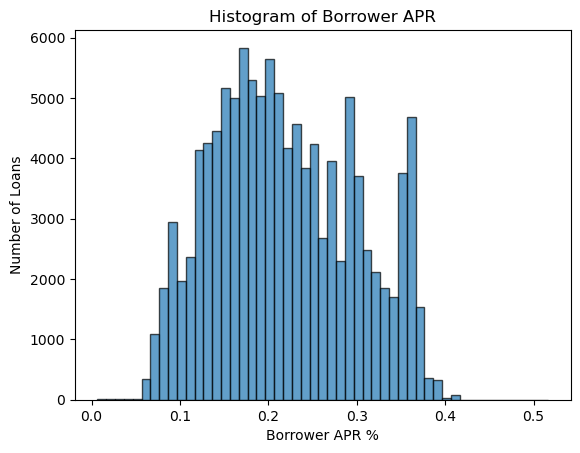

In [8]:
bin_width = 0.01
min_val = df['BorrowerAPR'].min()
max_val = df['BorrowerAPR'].max()
bin_edges = np.arange(min_val, max_val + bin_width, bin_width)

df['BorrowerAPR'].plot.hist(bins=bin_edges, edgecolor='black', alpha=0.7)
plt.title('Histogram of Borrower APR')
plt.xlabel('Borrower APR %')
plt.ylabel('Number of Loans')

Question: What are the most common loan amounts requested by borrowers?

In [9]:
# Check for null values
df['LoanOriginalAmount'].isnull().sum()

np.int64(0)

There are no null values.

Text(0, 0.5, 'Number of Loans')

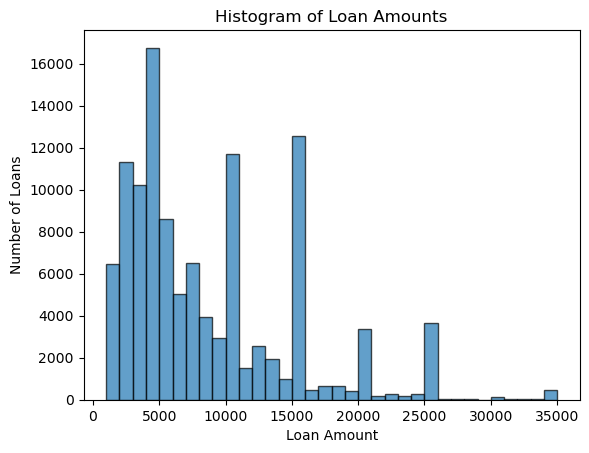

In [10]:
bin_width = 1000
min_val = df['LoanOriginalAmount'].min()
max_val = df['LoanOriginalAmount'].max()
bin_edges = np.arange(min_val, max_val + bin_width, bin_width)

df['LoanOriginalAmount'].plot.hist(bins=bin_edges, edgecolor='black', alpha=0.7)
plt.title('Histogram of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Loans')

Question: How are borrowers distributed across the platform's risk tiers?

In July 2009, Prosper introduced its own proprietary risk evaluation rating system to represent the estimated default risk of a borrower. It is a 7-tier scale ordered from lowest to highest risk:
AA: Lowest Risk — Top-tier prime borrowers with strong credit histories and low risk of default.
A: Low Risk
B: Medium-Low Risk
C: Moderate Risk — Represents the "average" borrower on the platform.
D: Medium-High Risk
E: High Risk
HR: High Risk (Subprime) — Borrowers with weak credit profiles or higher estimated default rates.

/var/folders/7c/07385tgs4yn6cjwc2d3_4bs80000gn/T/ipykernel_29804/2202501962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ProsperRating (Alpha)", data=df, palette="Set2", order = order_rankings)


Text(0, 0.5, 'Count')

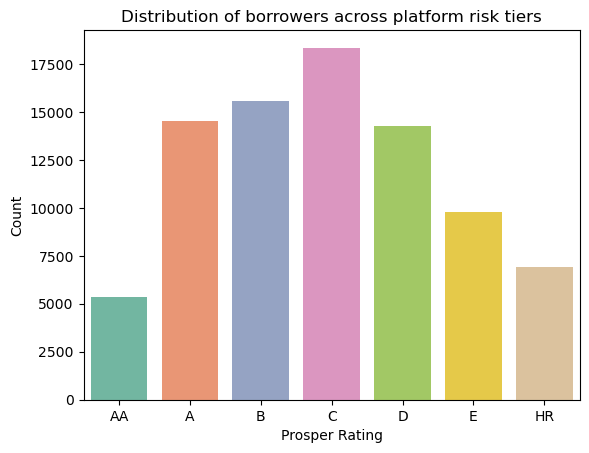

In [11]:
order_rankings = ['AA', 'A', 'B', 'C', 'D', 'E', 'HR']


sns.countplot(x="ProsperRating (Alpha)", data=df, palette="Set2", order = order_rankings)

plt.title("Distribution of borrowers across platform risk tiers")
plt.xlabel("Prosper Rating")
plt.ylabel("Count")

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> The distribution for BorrowerAPR is bell-shaped between 5% and 40% with the bulk of loans having a 10% to 25% APR. For loan amounts, the distribution is right-skewed with more people preferring to take on smaller loans. The distribution of Prosper ratings is roughly bell-shaped, peaking at middle-tier ratings B, C, and D. There are fewer borrowers in the lowest risk tier AA and highest risk tier HR.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> There is a notable sharp peak at around 29% and 36% for BorrowerAPR. I removed empty values to clean the data and show more accurate results. For loan amounts, there are unusual spikes for loan amounts that are multiples of 5000 like 500, 10000, etc. Nothing seems unusual about the distribution of the prosper ratings, as C represents the "average" borrower and has the most borrowers as expected.

## Bivariate Exploration

Question: What is the relationship between the original loan amount and the borrower's annual percentage rate? Do larger loans come with lower or higher APRs?

Overplotting: The dataset has over 113,000 loans which will end up causing a lot of overlap between points. To solve this I will take a sample of 10,000 loans and set a transparency value so that overlapping dots show where density is highest.

Text(0, 0.5, 'Borrower APR')

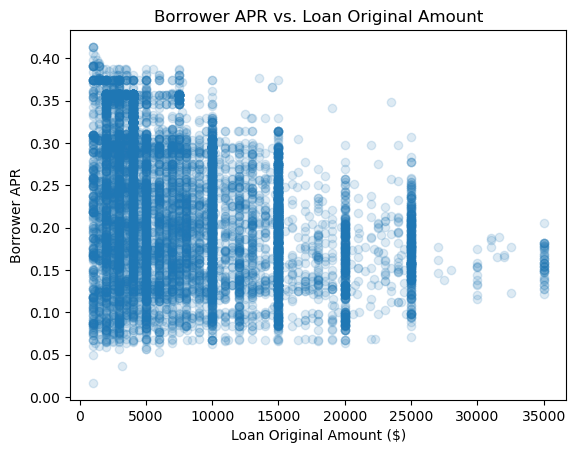

In [12]:
df_sample = df.sample(n=10000, random_state=42)

plt.scatter(data=df_sample, x='LoanOriginalAmount', y='BorrowerAPR', alpha=0.15)
plt.title('Borrower APR vs. Loan Original Amount')
plt.xlabel('Loan Original Amount ($)')
plt.ylabel('Borrower APR')

There are dense vertical lines at multiples of $5,000, and there is a wide spread for smaller loans ranging from 5% APR to 37% APR. Higher loan amounts have smaller APRs. There is a negative relationship.

Question: How does Borrower APR vary across the different Prosper ratings? Does a higher credit risk rating result in higher cost of borrowing?

/var/folders/7c/07385tgs4yn6cjwc2d3_4bs80000gn/T/ipykernel_29804/2706729167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ProsperRating (Alpha)", y="BorrowerAPR", order=order_rankings, palette="Blues")


Text(0, 0.5, 'Borrower APR')

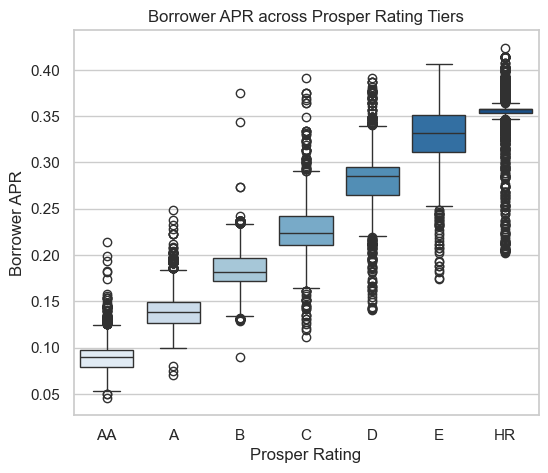

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x="ProsperRating (Alpha)", y="BorrowerAPR", order=order_rankings, palette="Blues")
plt.title('Borrower APR across Prosper Rating Tiers')
plt.xlabel('Prosper Rating')
plt.ylabel('Borrower APR')

We can see that as the borrower risk rating increases, so does the median value of the Borrower APR. At the highest ranking, data is compressed to around 35% indicating that 35-36% is the regulatory rate cap for APR. 

Question: Where is the greatest concentration of loans when looking at loan amounts versus APR?

Text(0, 0.5, 'Borrower APR')

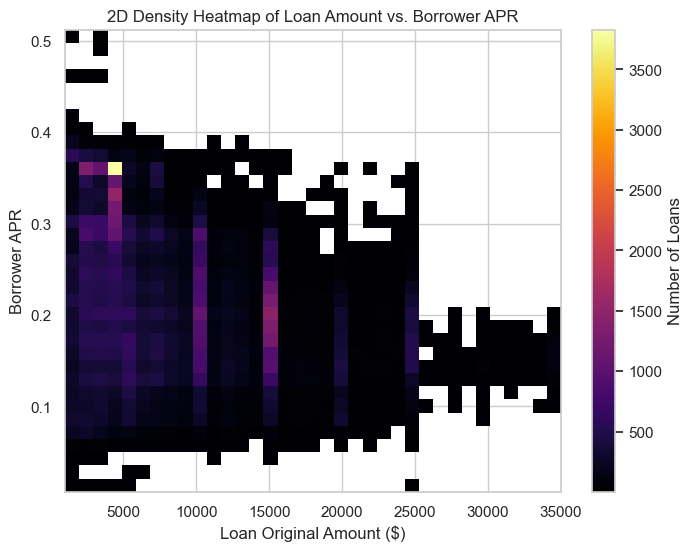

In [14]:
fig, ax = plt.subplots(figsize=(8,6))

plt.hist2d(
    data=df, x='LoanOriginalAmount', y='BorrowerAPR', cmin=1, cmap='inferno', bins=[35,35]
)

plt.colorbar(label="Number of Loans")

plt.title('2D Density Heatmap of Loan Amount vs. Borrower APR')
plt.xlabel('Loan Original Amount ($)')
plt.ylabel('Borrower APR')

We can see a single, intense hotspot for loans of $5,000 at high 36% APR. We can also see more loans being given out for $10k and $15k at lower APRs. High loans receive lower rates overall.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> 1. BorrowerAPR vs ProsperRating: The median APR climbs higher for each successive rank. Borrowers in the HR category are concentrated at the platform rate cap of around 35%.
> 2. BorrowerAPR vs LoanOriginalAmount: There is an overall negative relationship. Small loan amounts have a large variance of APRs, but there is a large concentration of loans of around $5,000 at around the rate cap of 35%. As the loan sizes grow, the maximum APR drops and we can see large loans don't have APRs past 20% for the most part.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> High APRs and large loan amounts are pretty much not present. High risk borrowers in Prosper Ratings HR and E are only approved for smaller loans capping at $5,000. 

## Multivariate Exploration

Big Question: Does a larger loan amount actually cause a lower APR on its own, or is it just that borrowers with top-tier ratings like AA and A are the only ones allowed to take out large loans?

Question 1: How does the relationship between the original loan amount and Borrower APR behave across each of the different Prosper rating tiers?

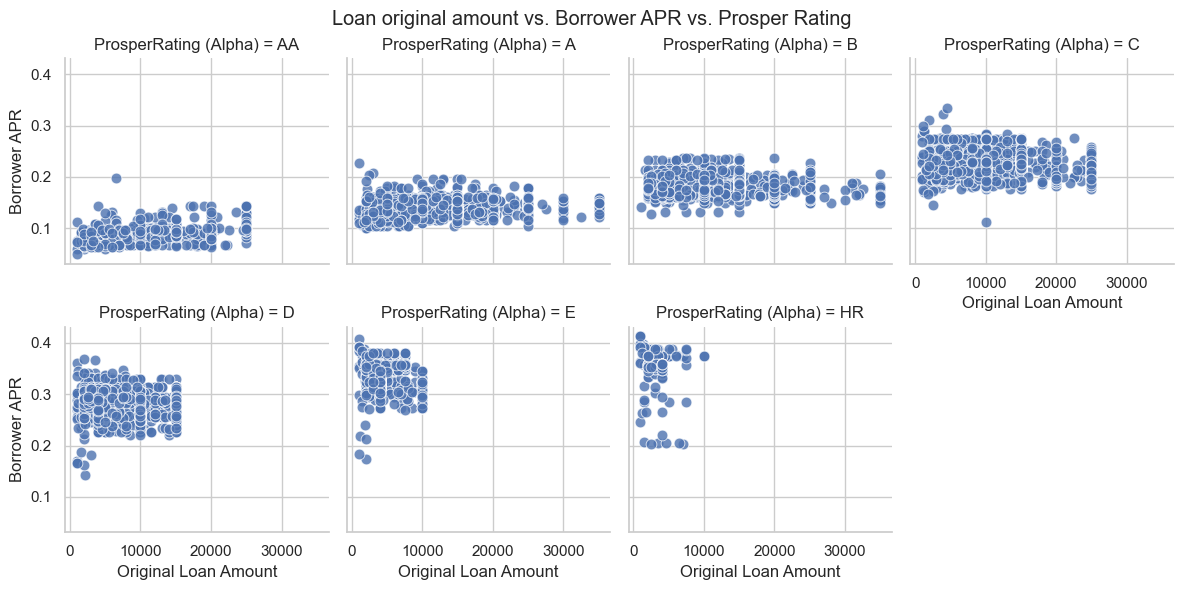

In [15]:
g = sns.FacetGrid(df_sample, col='ProsperRating (Alpha)', col_wrap=4, col_order=order_rankings)
g.map(sns.scatterplot, 'LoanOriginalAmount', 'BorrowerAPR', alpha=0.8, s=60)
g.set_axis_labels("Original Loan Amount", "Borrower APR")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Loan original amount vs. Borrower APR vs. Prosper Rating")
plt.show()

We can see that the lowest prosper rating, AA, has the lowest borrower APR rates with loans varying from small to large. As the risk rating increases, the borrower APR slowly increases as well and the loans that are given out get smaller.

Question 2: How do loan amounts and borrower APR vary across different loan terms (12, 36, and 60 months)? Do longer term loans allow borrowers to borrow more money, and how does term length affect the APR for these amounts?

Text(0, 0.5, 'Borrower APR')

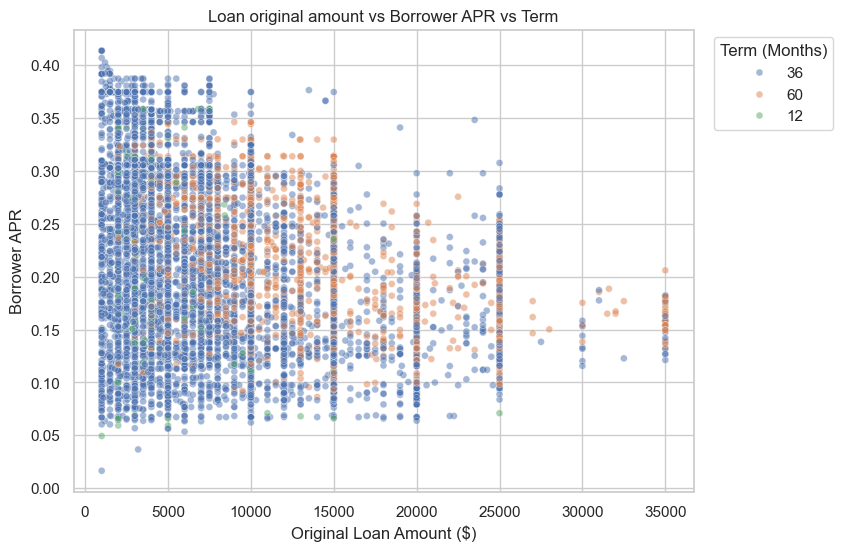

In [16]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_sample,
    x='LoanOriginalAmount',
    y='BorrowerAPR',
    hue=df_sample['Term'].astype(str),
    alpha=0.5,
    s=25
)

plt.legend(title='Term (Months)',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.title('Loan original amount vs Borrower APR vs Term')
plt.xlabel('Original Loan Amount ($)')
plt.ylabel('Borrower APR')

We can see there is a vast majority of 36-month terms notably for smaller loans. As the loans get bigger they start to coalesce in multiples of $5,000 and we see more 60-month terms in these multiples. There are very few 12-month terms visible.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> We saw that as the Prosper Rating got higher (more risk), the loan amounts lent out got smaller and smaller. The interest rate (APR) also got higher as the risk rating increases.

### Were there any interesting or surprising interactions between features?

> In my bivariate analysis, it initially looked like larger loans caused lower APRs. However the facet plot showed that the APR stays relatively flat for each risk rating tier which proves that credit rating affects APR and not loan size.

## Conclusions

I investigated the Prosper Loan dataset (113,937 loans) to understand what drives the cost of borrowing (BorrowerAPR). I wrangled the data by dropping missing APR values and establishing the ordinal hierarchy for ProsperRating from AA to HR. I then progressed from univariate to bivariate and then multivariate distributions using sampling and transparency to overcome overplotting. 

Key Findings:
- The APR distribution centered around 15-20% with a notable spike at 35% representing the platform's maximum interest rate cap. 
- Loan amounts cluster at increments of $5,000 with lower loan amounts being the most frequently requested.
- As borrower risk rating worsens from AA to HR, the median BorrowerAPR increases as shown in the box plot.
- In bivariate analysis, the loans appeared to correlate with lower APRs. However the multivariate facet grid showed that within any credit tier the relationship is flat. Higher-risk borrowers are capped at $4,000 with only low-risk borrowers petmitted to borrow $25,000+.
- The most dominant term is the 36-month term length. 12-month terms are rare and limited to smaller amounts while 60-month terms are reserved for larger balances ($10,000).